In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Combining ORD - Output Comparison

This notebook compares the combined results from running the split PiWind
exposure to a run of PiwWind with the full exposure set.

In [2]:
# run options

runtype = 'selt'
expected_summary_level = 2
generated_summary_level = expected_summary_level - 1

In [3]:
# Load files

assert runtype in ['qelt', 'selt', 'melt'], 'Runtype not recognised'

if runtype == 'qelt':
    generated_path = Path('../outputs/combined_ord-qelt')
elif runtype == 'melt': 
    generated_path = Path('../outputs/combined_ord-melt')
else:
    generated_path = Path('../outputs/combined_ord-selt')

expected_path = Path('../PiWindExample/full/runs/losses-20251210162054/output').expanduser()

### Compare summary-info

In [4]:
expected_summary_info = pd.read_csv(expected_path / f'gul_S{expected_summary_level}_summary-info.csv')
generated_summary_info = pd.read_csv(generated_path / f'gul_GS{generated_summary_level}_summary-info.csv')

In [5]:
if 'LocNumber' in generated_summary_info.columns:
    merged_df = generated_summary_info.merge(expected_summary_info, on='LocNumber',
                                             suffixes=['_generated', '_expected'])

    merged_df['tiv_diff'] = np.abs(merged_df['tiv_generated'] - merged_df['tiv_expected'])

    print(merged_df[['LocNumber', 'tiv_generated', 'tiv_expected', 'tiv_diff']])
else:
    print('Generated summary info: ')
    print(generated_summary_info)
    print('Expected summary info: ')
    print(expected_summary_info)

     LocNumber  tiv_generated  tiv_expected  tiv_diff
0  10002082046       220000.0      220000.0       0.0
1  10002082047       790000.0      790000.0       0.0
2  10002082048       160000.0      160000.0       0.0
3  10002082049        30000.0       30000.0       0.0
4  10002082050       250000.0      250000.0       0.0
5  10002082051       700000.0      700000.0       0.0
6  10002082052        90000.0       90000.0       0.0
7  10002082053       310000.0      310000.0       0.0
8  10002082054       420000.0      420000.0       0.0
9  10002082055       430000.0      430000.0       0.0


### Compare ALT

In [6]:
expected_aal = pd.read_csv(expected_path / f'gul_S{expected_summary_level}_palt.csv')
generated_aal_mean = pd.read_csv(generated_path / f'{generated_summary_level}_aal_mean.csv')
generated_aal_full = pd.read_csv(generated_path / f'{generated_summary_level}_aal_full.csv')

generated_aal_mean = generated_aal_mean.sort_values(by=['LossType',
                                                        'SummaryId']).reset_index(drop=True)
generated_aal_full = generated_aal_full.sort_values(by=['LossType',
                                                        'SummaryId']).reset_index(drop=True)

In [7]:
# mean only
generated_aal_mean['expected_loss'] = expected_aal['MeanLoss']
generated_aal_mean['expected_diff'] = np.abs(generated_aal_mean['expected_loss'] - generated_aal_mean['Mean'])
generated_aal_mean['diff_percent'] = generated_aal_mean['expected_diff'] / generated_aal_mean['Mean'] * 100
generated_aal_mean

,group_set_id,SummaryId,LossType,Mean,Std,expected_loss,expected_diff,diff_percent
0,1,1,1,15258.891977,32834.091523,15258.891977,0.000000,0.000000e+00
1,1,2,1,54793.293906,117904.237730,54793.293906,0.000000,0.000000e+00
2,1,3,1,11097.375939,23879.339261,11097.375939,0.000000,0.000000e+00
3,1,4,1,2080.757985,4477.376108,2080.757985,0.000000,0.000000e+00
4,1,5,1,17339.649879,37311.467573,17339.649879,0.000000,0.000000e+00
5,1,6,1,48551.019906,104472.109369,48551.019906,0.000000,0.000000e+00
6,1,7,1,6242.273988,13432.128348,6242.273988,0.000000,0.000000e+00
7,1,8,1,21501.165879,46266.219814,21501.165879,0.000000,0.000000e+00
8,1,9,1,29130.611953,62683.265632,29130.611953,0.000000,0.000000e+00
9,1,10,1,29824.197953,64175.724339,29824.197953,0.000000,0.000000e+00


In [8]:
# secondary uncertainty
generated_aal_full['expected_loss'] = expected_aal.query('SampleType==2').reset_index()['MeanLoss']
generated_aal_full['expected_diff'] = np.abs(generated_aal_full['expected_loss'] - generated_aal_full['Mean'])
generated_aal_full['diff_percent'] = generated_aal_full['expected_diff'] / generated_aal_full['Mean'] * 100
generated_aal_full

,group_set_id,SummaryId,LossType,Mean,Std,expected_loss,expected_diff,diff_percent
0,1,1,2,14796.538798,37435.831368,14940.773352,144.234554,0.974786
1,1,2,2,54314.996676,135281.995061,53929.959775,385.036901,0.708896
2,1,3,2,10809.896592,27074.488412,10939.078579,129.181987,1.195034
3,1,4,2,2042.729358,5099.630419,2042.802188,0.072830,0.003565
4,1,5,2,16941.836858,42563.396682,16889.927418,51.909440,0.306398
5,1,6,2,47625.479174,118277.496323,48155.918911,530.439737,1.113773
6,1,7,2,6105.796913,15291.733915,6115.324515,9.527602,0.156042
7,1,8,2,21484.983883,53524.073260,21392.477627,92.506256,0.430562
8,1,9,2,28535.439998,70802.312419,28890.503077,355.063079,1.244288
9,1,10,2,29063.819552,73203.482794,29387.891901,324.072349,1.115037


### Compare EP

In [9]:
# EP comparison options
mean_only = False
EPType = 1  # 1 = oep, 3 = aep

if mean_only:
    EP_Calc = 1
else:
    EP_Calc = 2

if EPType == 1:
    ep_ext = 'oep'
elif EPType == 3:
    ep_ext = 'aep'
else:
    raise Exception('EPType not supported')

total_group_periods = 10000

In [13]:
# Output directory to save plots + comaprison df
save_ep = False
output_dir = Path('../outputs/compare_ep/')

if not output_dir.exists():
    output_dir.mkdir(parents=True)

In [14]:
# load EP tables
mean_ext = 'mean' if mean_only else 'full'
dtypes_ep = {
    'group_set_id': 'int',
    'SummaryId': 'int',
    'EPCalc': 'int',
    'EPType': 'int',
    'RP': 'float',
    'Loss': 'float'
}

generated_ep = pd.read_csv(generated_path /
                           f'{generated_summary_level}_ep_{mean_ext}.csv').astype(dtypes_ep)

expected_ep = pd.read_csv(expected_path / f'gul_S{expected_summary_level}_ept.csv')

To compare EP tables we find the matching ReturnPeriods and compare + plot the EP tables.
Note this is done for each SummaryId separately. The plots and merged ep tables are output in the desired output path.

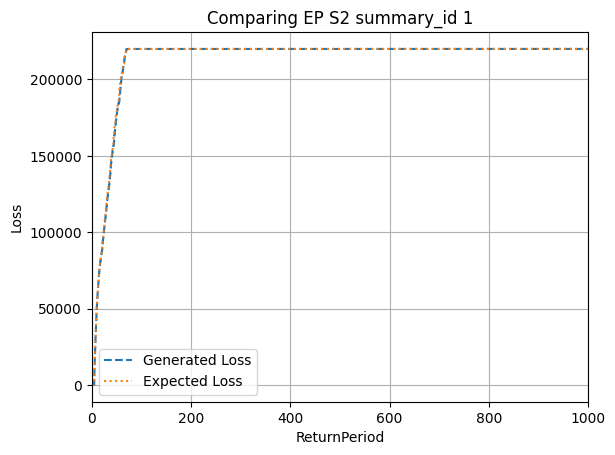

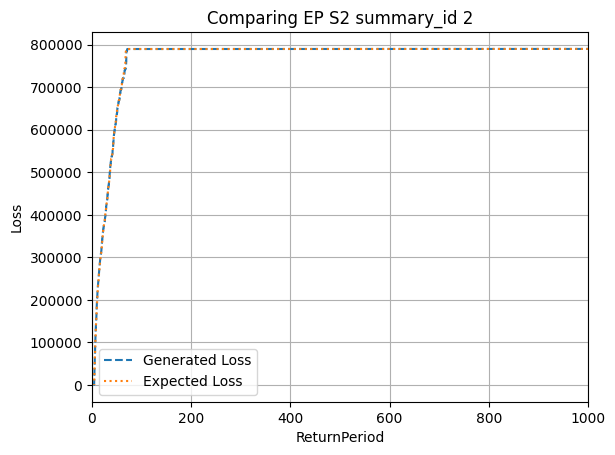

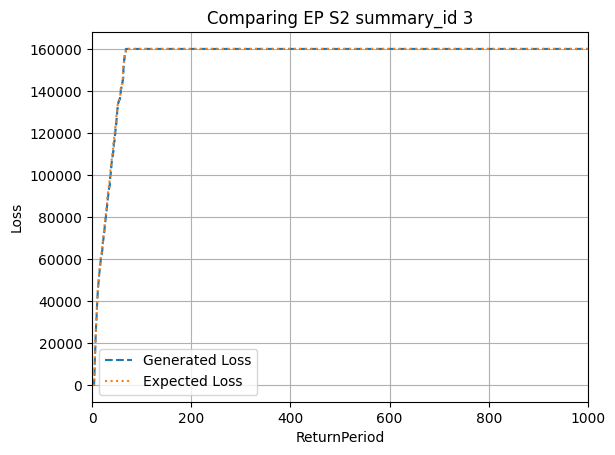

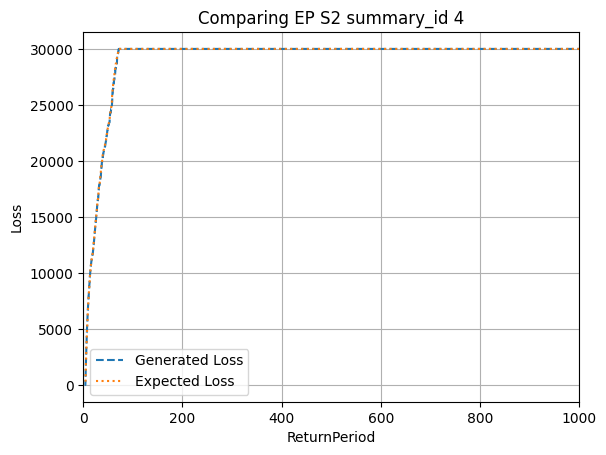

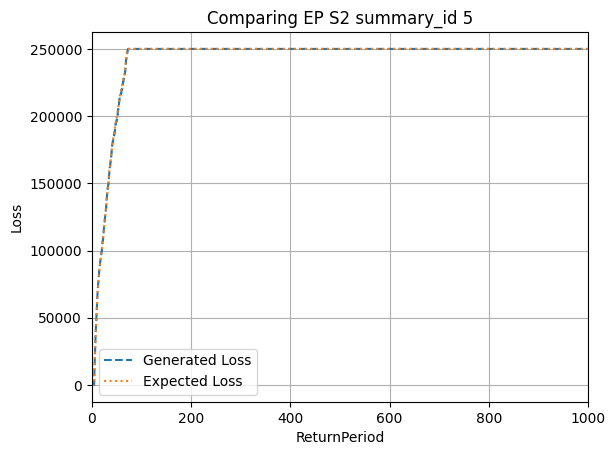

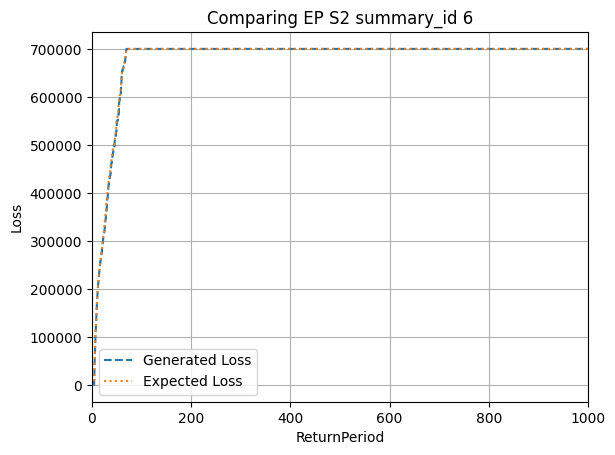

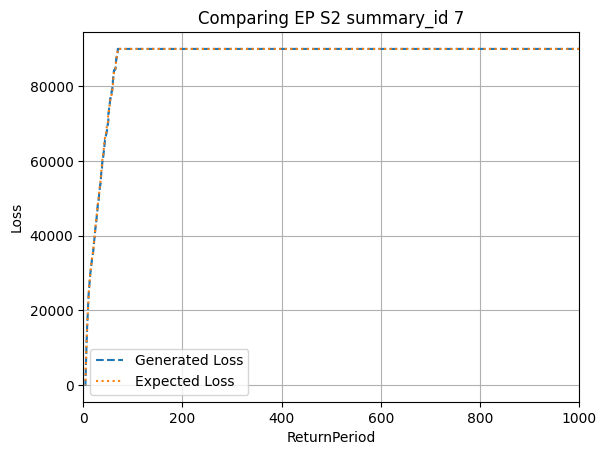

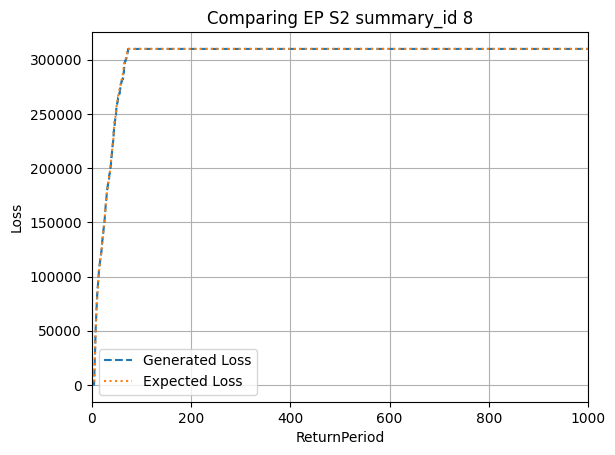

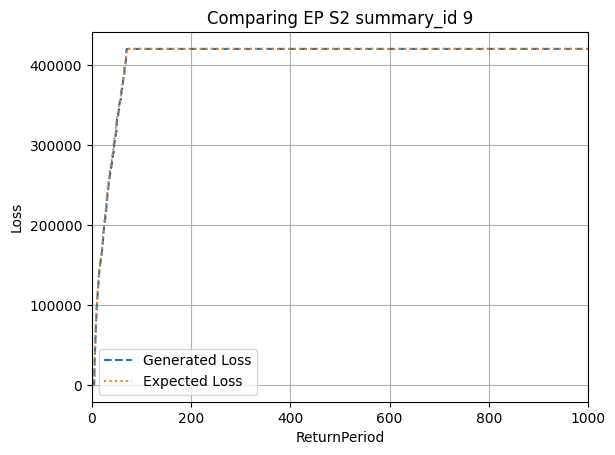

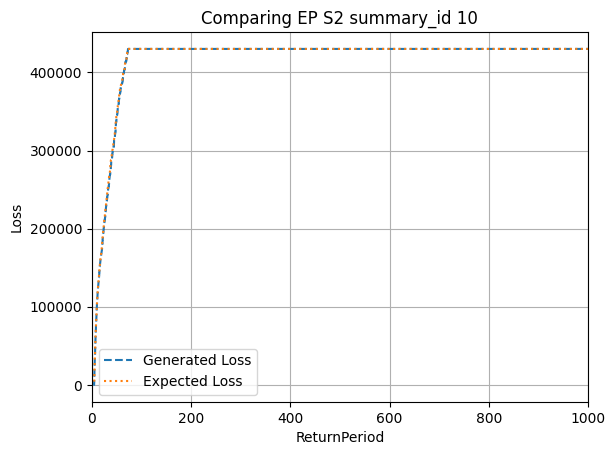

In [15]:
for summary_id in generated_ep['SummaryId'].unique():
    _generated_ep = generated_ep.query(f'SummaryId == {summary_id}')
    _expected_ep = expected_ep.query(f'SummaryId == {summary_id}')

# extract mean damage loss EP table
    mean_expected_ep = _expected_ep.query(f'EPCalc == {EP_Calc}')
    mean_generated_ep = _generated_ep.query(f'EPCalc == {EP_Calc}')

    ep_mean_expected_ep = mean_expected_ep.query(f'EPType=={EPType}')
    ep_mean_generated_ep = mean_generated_ep.query(f'EPType=={EPType}')

    # Aligning summary id
    filtered_oep_mean_generated_ep = ep_mean_generated_ep[ep_mean_generated_ep['RP'].isin(ep_mean_expected_ep['ReturnPeriod'])].reset_index(drop=True)

    filtered_oep_mean_expected_ep = ep_mean_expected_ep[ep_mean_expected_ep['ReturnPeriod'].isin(
        filtered_oep_mean_generated_ep['RP'])].reset_index(drop=True)

    to_merge_expected = filtered_oep_mean_expected_ep.filter(items=['ReturnPeriod', 'Loss'])
    merged_oep_mean_expected_ep = (filtered_oep_mean_generated_ep.filter(items=['RP', 'Loss'])
                                   .merge(to_merge_expected, left_on='RP', right_on='ReturnPeriod',
                                          suffixes=['_gen', '_expected']))

    merged_oep_mean_expected_ep['Loss_Diff'] = np.abs(merged_oep_mean_expected_ep['Loss_expected'] - merged_oep_mean_expected_ep['Loss_gen'])

    merged_oep_mean_expected_ep['Percent_Diff'] = merged_oep_mean_expected_ep['Loss_Diff'] / merged_oep_mean_expected_ep['Loss_gen'] * 100.0



    max_ret_period = ep_mean_expected_ep['ReturnPeriod'].max()
    gen_oep_in_range = ep_mean_generated_ep.query(f'RP <= {max_ret_period}')

    xlim = (0, 1000)
    ax = (gen_oep_in_range.rename(columns={'Loss': 'Generated Loss'})
          .plot('RP', 'Generated Loss', style=['--'], xlim=xlim,
                title=f'Comparing EP S{expected_summary_level} summary_id {summary_id}')
          )
    ep_mean_expected_ep.rename(columns={'Loss': 'Expected Loss'}).plot('ReturnPeriod', 'Expected Loss',
                                                                       ylabel='Loss', grid=True,
                                                                       xlim=xlim, ax=ax, style=[':'])
    if save_ep: 
        merged_oep_mean_expected_ep.to_csv(output_dir / f'{runtype}_{mean_ext}_{ep_ext}_gen_expected_merged_S{expected_summary_level}_id{summary_id}.csv', index=False)
        fig_path = output_dir / f'{runtype}_{mean_ext}_{ep_ext}_{expected_summary_level}_id{summary_id}.png'
        print(f'Saving figure in: {fig_path}')
        plt.savefig(fig_path)
        plt.close()
    else: 
        plt.show()
